In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
from functools import reduce
from functools import partial
import sys
import os
# use google drive
data_path = "./data/Re_1280.h5"
sys.path.append('/content/drive/MyDrive/Research/Winter 2025/FNO')
import h5py
import numpy as np
from timeit import default_timer
import operator


## Defining models

Here we define layers/definitions for our UNet models. Can easily be replaced with other models.

In [3]:
def conv(in_planes, output_channels, kernel_size, stride, dropout_rate):
    return nn.Sequential(
        nn.Conv2d(in_planes, output_channels, kernel_size=kernel_size,
                  stride=stride, padding=(kernel_size - 1) // 2, bias = False),
        nn.BatchNorm2d(output_channels),
        nn.LeakyReLU(0.1, inplace=True),
        nn.Dropout(dropout_rate)
    )

def deconv(input_channels, output_channels):
    return nn.Sequential(
        nn.ConvTranspose2d(input_channels, output_channels, kernel_size=4,
                           stride=2, padding=1),
        nn.LeakyReLU(0.1, inplace=True)
    )

def output_layer(input_channels, output_channels, kernel_size, stride, dropout_rate):
    return nn.Conv2d(input_channels, output_channels, kernel_size=kernel_size,
                     stride=stride, padding=(kernel_size - 1) // 2)

class U_net(nn.Module):
    def __init__(self, input_channels=2, output_channels=2, kernel_size=5, dropout_rate=0.1):
        super(U_net, self).__init__()
        self.input_channels = input_channels
        self.conv1 = conv(input_channels, 64, kernel_size=kernel_size, stride=2, dropout_rate = dropout_rate)
        self.conv2 = conv(64, 128, kernel_size=kernel_size, stride=2, dropout_rate = dropout_rate)
        self.conv3 = conv(128, 256, kernel_size=kernel_size, stride=2, dropout_rate = dropout_rate)
        self.conv3_1 = conv(256, 256, kernel_size=kernel_size, stride=1, dropout_rate = dropout_rate)
        self.conv4 = conv(256, 512, kernel_size=kernel_size, stride=2, dropout_rate = dropout_rate)
        self.conv4_1 = conv(512, 512, kernel_size=kernel_size, stride=1, dropout_rate = dropout_rate)
        self.conv5 = conv(512, 1024, kernel_size=kernel_size, stride=2, dropout_rate = dropout_rate)
        self.conv5_1 = conv(1024, 1024, kernel_size=kernel_size, stride=1, dropout_rate = dropout_rate)

        self.deconv4 = deconv(1024, 256)
        self.deconv3 = deconv(768, 128)
        self.deconv2 = deconv(384, 64)
        self.deconv1 = deconv(192, 32)
        self.deconv0 = deconv(96, 16)

        self.output_layer = output_layer(16 + input_channels, output_channels,
                                         kernel_size=kernel_size, stride=1, dropout_rate = dropout_rate)

    def match_dims(self, x1, x2):
        diffY = x2.size()[2] - x1.size()[2]
        diffX = x2.size()[3] - x1.size()[3]

        x1 = F.pad(x1, [diffX // 2, diffX - diffX // 2,
                        diffY // 2, diffY - diffY // 2])

        return torch.cat([x2, x1], dim = 1)

    def forward(self, x):
        # identity = x
        out_conv1 = self.conv1(x)
        out_conv2 = self.conv2(out_conv1)
        out_conv3 = self.conv3_1(self.conv3(out_conv2))
        out_conv4 = self.conv4_1(self.conv4(out_conv3))
        out_conv5 = self.conv5_1(self.conv5(out_conv4))

        out_deconv4 = self.deconv4(out_conv5)
        concat4 = self.match_dims(out_deconv4, out_conv4)
        out_deconv3 = self.deconv3(concat4)
        concat3 = self.match_dims(out_deconv3, out_conv3)
        out_deconv2 = self.deconv2(concat3)
        concat2 = self.match_dims(out_deconv2, out_conv2)
        out_deconv1 = self.deconv1(concat2)
        concat1 = self.match_dims(out_deconv1, out_conv1)
        out_deconv0 = self.deconv0(concat1)
        concat0 = self.match_dims(out_deconv0, x)
        out = self.output_layer(concat0)
        # out = out + identity

        return out

## Defining data loaders

MatReader class just makes it easier to deal with loading the mat files.

In [4]:
class MatReader(object):
    def __init__(self, file_path, to_torch=True, to_cuda=False, to_float=True, testing=True):
        super(MatReader, self).__init__()

        self.to_torch = to_torch
        self.to_cuda = to_cuda
        self.to_float = to_float
        self.testing = testing

        self.file_path = file_path

        self.data = None
        self.old_mat = None
        self._load_file()

    def _load_file(self):
          self.data = h5py.File(self.file_path)
          self.old_mat = False

    def load_file(self, file_path):
        self.file_path = file_path
        self._load_file()

    def read_field(self, field):
        if not self.testing:
          x = self.data[field]
        else:
          x = self.data[field][:,:,:,:100]

        if not self.old_mat:
            x = x[()]
            x = np.transpose(x, axes=range(len(x.shape) - 1, -1, -1))

        if self.to_float:
            x = x.astype(np.float32)

        if self.to_torch:
            x = torch.from_numpy(x)

            if self.to_cuda:
                x = x.cuda()

        return x

    def set_cuda(self, to_cuda):
        self.to_cuda = to_cuda

    def set_torch(self, to_torch):
        self.to_torch = to_torch

    def set_float(self, to_float):
        self.to_float = to_float


Now we define a FluidDataset class to play nicely with torch.

In [5]:
class FluidDataset(torch.utils.data.Dataset):
  def __init__(self, u0_data, target_data):
    self.u0_data = u0_data
    self.target_data = target_data

  def __len__(self):
    return len(self.u0_data)

  def __getitem__(self, idx):
    return {'u0': self.u0_data[idx],
            'targets': self.target_data[idx]}

## Defining training variables

Here we do some housekeeping and define the expected geometry of our task. Specifically, we:
* Seed/set our torch device
* Set the total number of consecutive timesteps we expect per sequence
* Set the expected dimension of the data
* Set how many timesteps we want to use as input to our model
* Set how many timesteps we want to predict forward

In [ ]:
# Some housekeeping
seed = 5496#20250913#11519#
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
np.random.seed(seed)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# How many timesteps are in the dataset (should usually remain hardcoded at 12, but we do have some longer data)
T_len = 12

# Dimensions of the PIV data
S1 = 100 # changed from 138 to 100 to match Re_1280.h5
S2 = 89

# How many timesteps to use as input for the prediction. Usually 1 or 2
T_in = 1

# How many timesteps to predict forward. Could be as many as T_len - T_in.
T_out = 10

Here we set the network/training parameters. Note that we have a "testing" mode which will allow us to train/test things faster when trying to debug, ect.

In [7]:

testing = False

if testing:
    ntrain = 32
    ntest = 32
    epochs = 10
else:
    # Number of sequences to use in the training set
    ntrain = 16*218
    # Number of sequences to use in the testing set
    ntest = 16*52
    # Number of epochs to train for
    epochs = 200

# Setting the batch size:
batch_size = 32

# Setting speed parameter
speed = "5Hz_200fps"

In [8]:
def count_params(model):
    c = 0
    for p in list(model.parameters()):
        c += reduce(operator.mul,
                    list(p.size()+(2,) if p.is_complex() else p.size()))
    return c


## Loading data



Here we actually load our data using MatReader

In [9]:
# File where the data is. Note that we usually use the 't12_dt5_clean.mat' files.
fname = data_path

reader = MatReader(fname, testing=testing)

Actually read in and arrange the data

In [10]:
# X and Y components of velocity are stored separately
u_x = reader.read_field('u_x')
u_y = reader.read_field('u_y')

u_x = u_x.permute(3, 2, 1, 0)
u_y = u_y.permute(3, 2, 1, 0)

p = np.random.permutation(len(u_x))
u_x = u_x[p]
u_y = u_y[p]

u_x_mean = u_x[:ntrain, ...].mean()
u_x_std = u_x[:ntrain, ...].std()
u_y_mean = u_y[:ntrain, ...].mean()
u_y_std = u_y[:ntrain, ...].std()

u_x = (u_x - u_x_mean) / u_x_std
u_y = (u_y - u_y_mean) / u_y_std

# Model inputs for training
train_a_x = u_x[:ntrain, :, :, :T_in]
train_a_y = u_y[:ntrain, :, :, :T_in]
train_a = torch.stack((train_a_x, train_a_y), -1)
train_a = torch.flatten(train_a, -2)  # This will need to change if i move to 2 input steps again
train_a = torch.permute(train_a, (0, 3, 1, 2))

# Model inputs for testing
test_a_x = u_x[-ntest:, :, :, :T_in]
test_a_y = u_y[-ntest:, :, :, :T_in]
test_a = torch.stack((test_a_x, test_a_y), -1)
test_a = torch.flatten(test_a, -2) # This will need to change if i move to 2 input steps again
test_a = torch.permute(test_a, (0, 3, 1, 2))

# Target velocities for training
train_u_x = u_x[:ntrain, :, :, T_in:T_out + T_in]
train_u_y = u_y[:ntrain, :, :, T_in:T_out + T_in]
train_u = torch.stack((train_u_x, train_u_y), -1)
# train_u = torch.flatten(train_u, -2) # Changed
train_u = torch.permute(train_u, (0, 3, 4, 1, 2))

# Target velocities for testing
test_u_x = u_x[-ntest:,:,:,T_in:T_out + T_in]
test_u_y = u_y[-ntest:,:,:,T_in:T_out + T_in]
test_u = torch.stack((test_u_x, test_u_y), -1)
# test_u = torch.flatten(test_u, -2) # Changed
test_u = torch.permute(test_u, (0, 3, 4, 1, 2))

print("train_u_x:", train_u_x.shape)
print("stacked:", torch.stack((train_u_x, train_u_y), -1).shape)
print("train_u:", train_u.shape)

# Make sure things are the size we expect
assert (S2 == train_u.shape[-1])
assert (S1 == train_u.shape[-2])

# Build our training and testing datasets
train_dataset = FluidDataset(train_a, train_u)
test_dataset = FluidDataset(test_a, test_u)

# Build torch dataloaders from our datasets
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True, num_workers=4, pin_memory=True)#, persistent_workers=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False) # Don't shuffle the test_loader

train_u_x: torch.Size([477, 100, 89, 10])
stacked: torch.Size([477, 100, 89, 10, 2])
train_u: torch.Size([477, 10, 2, 100, 89])


In [11]:
u_x.shape

torch.Size([477, 100, 89, 133])

## Defining training functions

Now we define functions that we will use for training

In [12]:
#loss function with rel/abs Lp loss
class LpLoss(object):
    def __init__(self, d=2, p=2, size_average=True, reduction=True):
        super(LpLoss, self).__init__()

        #Dimension and Lp-norm type are postive
        assert d > 0 and p > 0

        self.d = d
        self.p = p
        self.reduction = reduction
        self.size_average = size_average

    def abs(self, x, y):
        num_examples = x.size()[0]

        #Assume uniform mesh
        h = 1.0 / (x.size()[1] - 1.0)
        all_norms = (h**(self.d/self.p))*torch.norm(x.view(num_examples,-1) - y.view(num_examples,-1), self.p, 1)

        if self.reduction:
            if self.size_average:
                return torch.mean(all_norms)
            else:
                return torch.sum(all_norms)

        return all_norms

    def rel(self, x, y):
        num_examples = x.size()[0]

        diff_norms = torch.norm(x.reshape(num_examples,-1) - y.reshape(num_examples,-1), self.p, 1)
        y_norms = torch.norm(y.reshape(num_examples,-1), self.p, 1)

        if self.reduction:
            if self.size_average:
                return torch.mean(diff_norms/y_norms)
            else:
                return torch.sum(diff_norms/y_norms)
        return diff_norms/y_norms

    def __call__(self, x, y):
        return self.rel(x, y)


In [13]:
import torch
import torch.nn as nn
import torch.optim as optim
from timeit import default_timer
import matplotlib.pyplot as plt
import math
import numpy as np

def train_recursive(
      model,
      train_dataloader,
      test_dataloader,
      num_steps=10,
      num_epochs=200,
      lr=1e-3,
      weight_decay=1e-4,
      warmup_epochs=5,
      clip_grad=0.5,
      plot_interval=10,
      device="cuda",
      teacher_forcing=False,
      early_stopping_patience=30,
      u_x_std=1.0,
      u_y_std=1.0,
      ):

    model = model.to(device)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.MSELoss()

    if teacher_forcing:
        print("WARNING: Teacher forcing enabled.")

    # # cosine annealing with warmup
    def lr_lambda(epoch):
        if epoch < warmup_epochs:
            return (epoch + 1) / warmup_epochs
        progress = (epoch - warmup_epochs) / max(1, (num_epochs - warmup_epochs))
        return 0.5 * (1 + math.cos(math.pi * progress))  # cosine from 1 → 0
    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lr_lambda)

    train_losses, test_losses = [], []
    train_losses_scaled, test_losses_scaled = [], []

    best_val_loss = float("inf")
    best_state_dict = None
    patience_counter = 0

    for epoch in range(num_epochs):
        t1 = default_timer()
        epoch_loss = 0.0
        epoch_loss_scaled = 0.0

        # teacher forcing schedule (decays linearly)
        tf_ratio = 1.0 - 0.5 * (epoch / num_epochs) if teacher_forcing else 0.0

        for batch in train_dataloader:
            u0 = batch['u0'].to(device, non_blocking=True)
            targets = batch['targets'].to(device, non_blocking=True)

            optimizer.zero_grad()
            predictions = [u0]
            u_current = u0

            # recursive rollout with optional teacher forcing
            for t in range(num_steps):
                u_next = model(u_current)
                predictions.append(u_next)

                if torch.rand(1).item() < tf_ratio:
                    u_current = targets[:, t]  # ground truth
                else:
                    u_current = u_next

            # loss over all horizons
            loss = 0.0
            loss_x = 0.0
            loss_y = 0.0
            for t in range(1, len(predictions)):
                loss += criterion(predictions[t], targets[:, t-1])
                loss_x += criterion(predictions[t][:, 0], targets[:, t-1][:, 0])
                loss_y += criterion(predictions[t][:, 1], targets[:, t-1][:, 1])
            loss = loss / num_steps
            loss_x = loss_x * u_x_std**2
            loss_y = loss_y * u_y_std**2
            # The factor of 2 makes the loss actually match original units
            loss_scaled = (loss_x + loss_y) / (2 *num_steps)

            loss.backward()

            # Print gradients
            # total_norm = torch.norm(torch.stack([p.grad.detach().norm(2) for p in model.parameters() if p.grad is not None]), 2)
            # print(f"Grad norm: {total_norm.item():.3f}")

            if clip_grad is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), clip_grad)
            optimizer.step()
            epoch_loss += loss.item()
            epoch_loss_scaled += loss_scaled.item()

        avg_train_loss = epoch_loss / len(train_dataloader)
        avg_train_loss_scaled = epoch_loss_scaled / len(train_dataloader)

        train_losses.append(avg_train_loss)
        train_losses_scaled.append(avg_train_loss_scaled)

        # validation
        model.eval()
        epoch_test_loss = 0.0
        epoch_test_loss_scaled = 0.0
        with torch.no_grad():
            for batch in test_dataloader:
                u0 = batch['u0'].to(device)
                targets = batch['targets'].to(device)
                predictions = recursive_prediction(model, u0, num_steps=num_steps, device=device)
                loss = 0.0
                loss_x = 0.0
                loss_y = 0.0
                for t in range(1, len(predictions)):
                    loss += criterion(predictions[t], targets[:, t-1])
                    loss_x += criterion(predictions[t][:, 0], targets[:, t-1][:, 0])
                    loss_y += criterion(predictions[t][:, 1], targets[:, t-1][:, 1])
                loss = loss / num_steps
                loss_x = loss_x * u_x_std**2
                loss_y = loss_y * u_y_std**2
                loss_scaled = (loss_x + loss_y) / (2 * num_steps)
                epoch_test_loss += loss.item()
                epoch_test_loss_scaled += loss_scaled.item()
        model.train()
        avg_test_loss = epoch_test_loss / len(test_dataloader)
        avg_test_loss_scaled = epoch_test_loss_scaled / len(test_dataloader)
        test_losses.append(avg_test_loss)
        test_losses_scaled.append(avg_test_loss_scaled)

        model.train()
        scheduler.step()

        t2 = default_timer()
        print(f"Epoch {epoch+1}/{num_epochs}, "
              f"Train Loss: {avg_train_loss_scaled:.8f}, "
              f"Test Loss: {avg_test_loss_scaled:.8f}, "
              f"Time: {t2 - t1:.2f}s, "
              f"LR: {scheduler.get_last_lr()[0]:.2e}")

        # early stopping logic
        if avg_test_loss < 0.99 * best_val_loss:  # small tolerance
            best_val_loss = avg_test_loss
            best_state_dict = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= early_stopping_patience:
                print(f"Early stopping at epoch {epoch+1}. Best val loss: {best_val_loss:.8f}")
                break

        if (epoch+1) % plot_interval == 0:
            # plot_velocity_field(predictions)
            plt.plot(train_losses_scaled, label="training")
            plt.plot(test_losses_scaled, label="testing")
            plt.yscale('log') # Added log scale to y-axis
            plt.xlabel('Epoch')
            plt.ylabel('Loss')
            plt.title('Training/Validation Loss')
            plt.legend()
            plt.show()


    # restore best weights
    if best_state_dict is not None:
        model.load_state_dict(best_state_dict)

    # Plot
    plt.plot(train_losses, label="training")
    plt.plot(test_losses, label="testing")
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training/Validation Loss')
    plt.legend()
    plt.show()

    return train_losses, test_losses, best_val_loss


def recursive_prediction(model, u0, num_steps=10, device="cuda"):
    # model.eval()
    predictions = [u0]
    u_current = u0
    with torch.no_grad():
        for t in range(num_steps):
            u_next = model(u_current.to(device))
            predictions.append(u_next)
            u_current = u_next
    # model.train()
    return predictions


# Plotting utility
def plot_velocity_field(preds):
    """
    Plots the 2D velocity field (u, v) for all timesteps in the predictions.

    Args:
        preds: A list of tensors, where each tensor represents the predicted
               velocity field at a particular timestep. The shape of each tensor
               should be (batch_size, 2, height, width).
    """
    num_timesteps = len(preds)

    for t in range(num_timesteps):
        # Get the prediction for the current timestep
        pred_t = preds[t]

        # Assuming batch_size = 1, get u and v components
        u = pred_t[0, 0].cpu().detach().numpy()  # x-component
        v = pred_t[0, 1].cpu().detach().numpy()  # y-component

        H, W = u.shape
        X, Y = np.meshgrid(np.linspace(0, 1, W), np.linspace(0, 1, H))

        fig, axes = plt.subplots(1, 3, figsize=(18, 5))

        # Plot u (horizontal velocity)
        im0 = axes[0].imshow(u, origin="lower", extent=[0, 1, 0, 1], cmap="RdBu")
        axes[0].set_title(f"u-component (horizontal), t={t}")
        fig.colorbar(im0, ax=axes[0])

        # Plot v (vertical velocity)
        im1 = axes[1].imshow(v, origin="lower", extent=[0, 1, 0, 1], cmap="RdBu")
        axes[1].set_title(f"v-component (vertical), t={t}")
        fig.colorbar(im1, ax=axes[1])

        # Plot vector field (quiver)
        step = 5  # downsample for visualization
        axes[2].quiver(X[::step, ::step], Y[::step, ::step], u[::step, ::step], v[::step, ::step])
        axes[2].set_title(f"Velocity Field (quiver), t={t}")
        axes[2].set_xlim(0, 1)
        axes[2].set_ylim(0, 1)

        plt.tight_layout()
        plt.show()

## Training

Now we're ready to train!

In [14]:
# Define the model and put it on the GPU (or other device).
# Can also change model parameters (e.g., input_channels, output_channels, etc.)
model = U_net(input_channels=2, output_channels=2, kernel_size=5, dropout_rate=0.2).to(device)

# Train the model using recursive prediction
print(f"Total number of parameters: {count_params(model)}")
# tags
tags = "FINAL_2"

epochs = 200
train_losses, test_losses, best_val_losses = train_recursive(model
                                                             , train_loader
                                                             , test_loader
                                                             , num_steps=T_out
                                                             , num_epochs=epochs
                                                             , plot_interval=10
                                                             , teacher_forcing=False
                                                             , clip_grad=0.5
                                                             , early_stopping_patience=30
                                                             , u_x_std=u_x_std
                                                             , u_y_std=u_y_std)


Total number of parameters: 58109814
Epoch 1/200, Train Loss: 0.00083009, Test Loss: 0.00038818, Time: 14.78s, LR: 4.00e-04
Epoch 2/200, Train Loss: 0.00014150, Test Loss: 0.00012485, Time: 14.17s, LR: 6.00e-04


KeyboardInterrupt: 

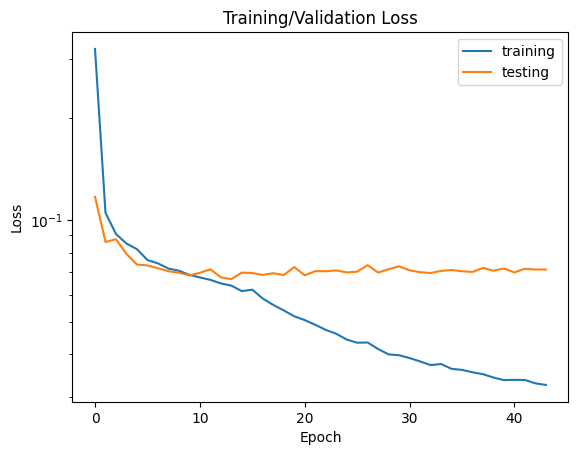

In [ ]:
    plt.plot(train_losses, label="training")
    plt.plot(test_losses, label="testing")
    plt.yscale('log') # Added log scale to y-axis
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training/Validation Loss')
    plt.legend()
    plt.show()



## Evaluating and saving


Defining a function to run the fully trained model on our test data.

In [ ]:
def test_recursive(model, dataloader, num_steps=10):
    # We want to put the model in evaluate mode now to get rid of any
    model.eval()
    u_actual = []
    u_pred = []
    with torch.no_grad():
      for batch in dataloader:
          # Expected batch keys:
          # 'u0': initial velocity field, shape (batch_size, 2, 89, 144)
          # 'targets': ground truth evolution for next num_steps timesteps,
          #            shape (batch_size, num_steps, 2, 89, 144)
          u0 = batch['u0'].to(device)
          targets = batch['targets'].to(device)
          u_actual.append(torch.cat((u0.unsqueeze(1), targets), dim=1))

          predictions = recursive_prediction(model, u0, num_steps=num_steps)
          u_pred.append(torch.stack(predictions, dim=1))
          # predictions is a list of length (num_steps+1): first element is u0, then each future timestep
    plot_velocity_field(predictions)
    u_actual = torch.cat(u_actual, dim=0).permute(2, 0, 3, 4, 1)
    u_pred = torch.cat(u_pred, dim=0).permute(2, 0, 3, 4, 1)
    return u_actual, u_pred



Run this and save it

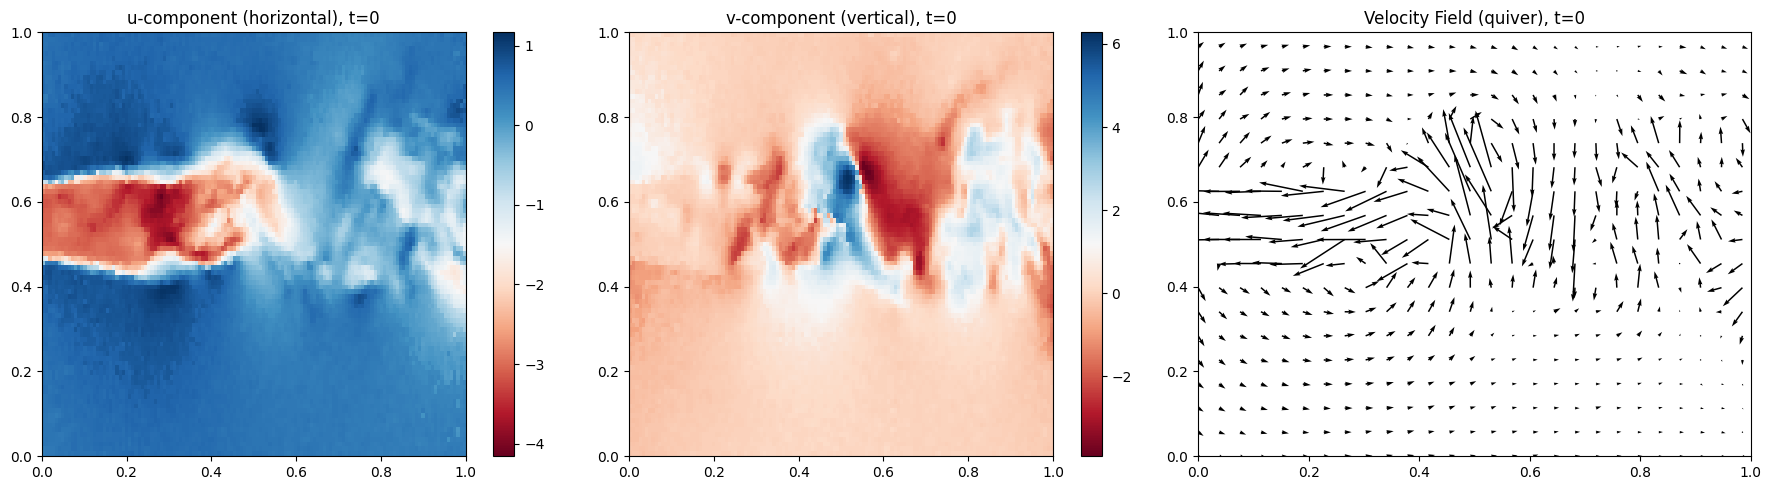

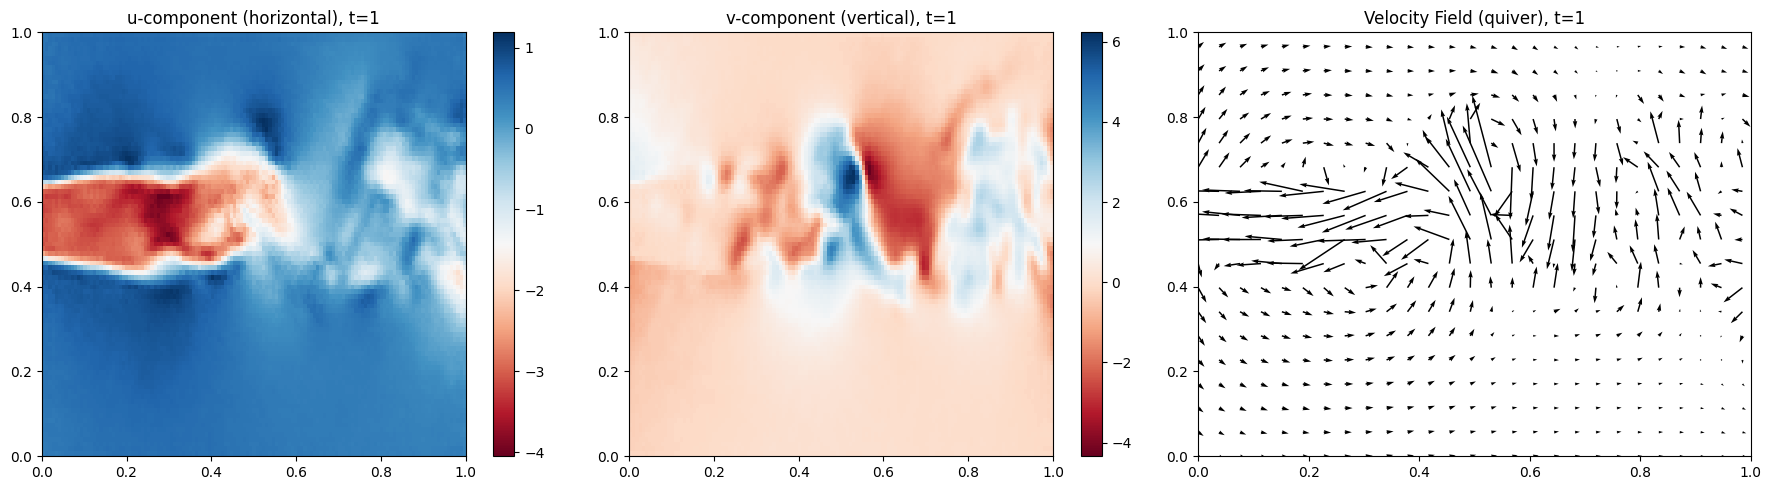

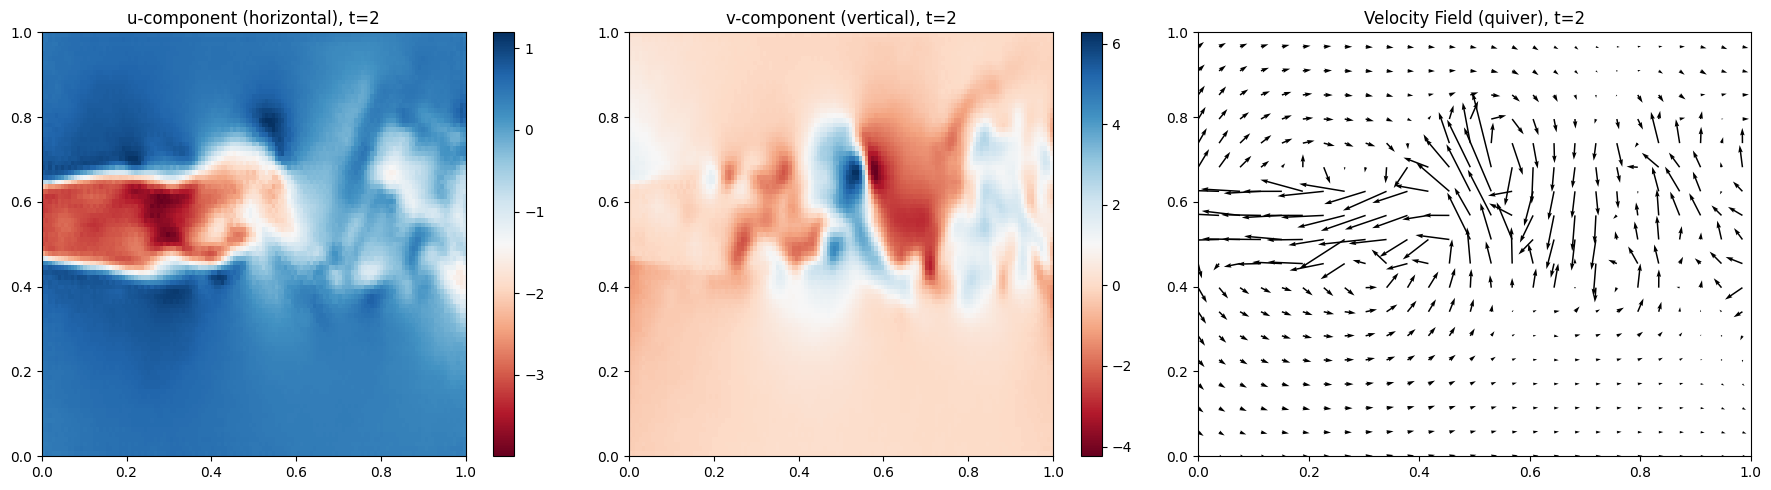

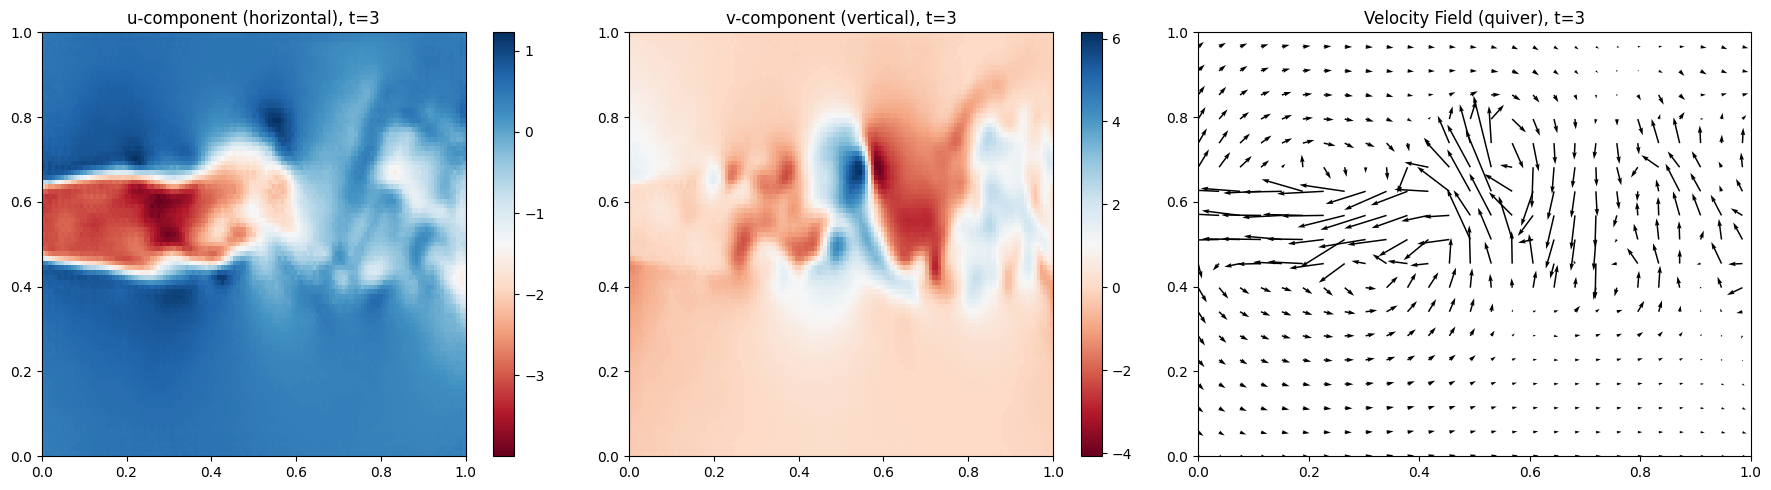

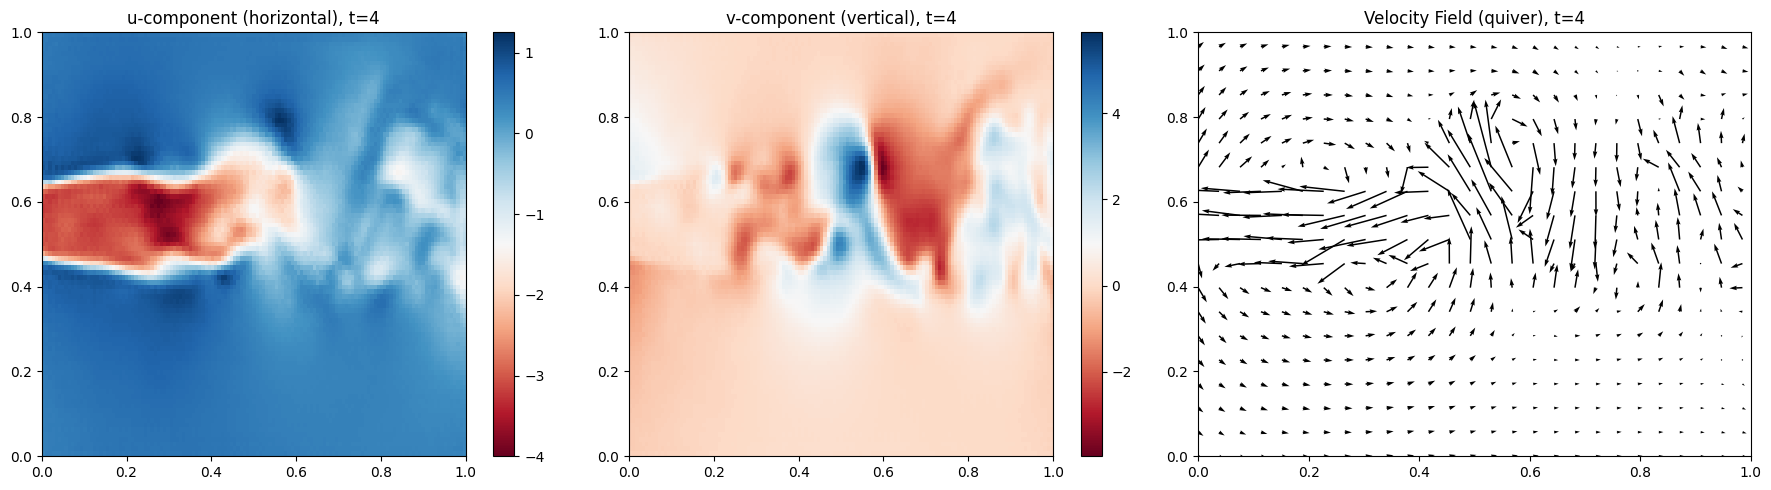

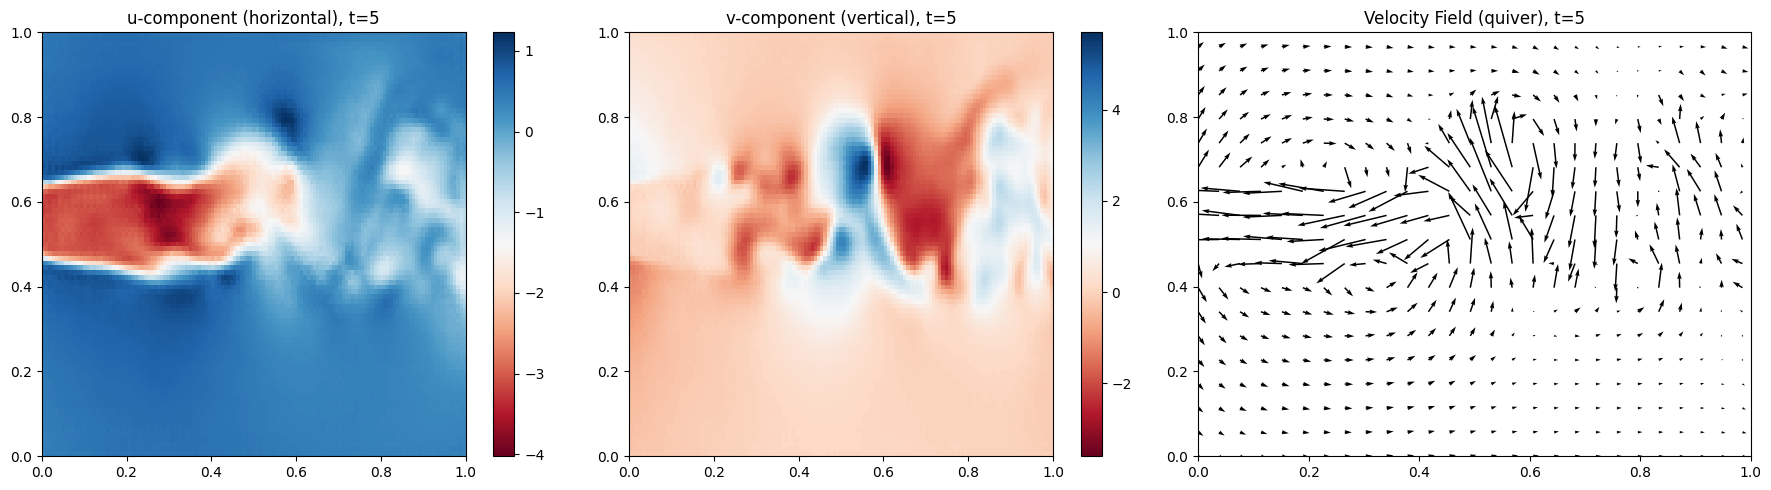

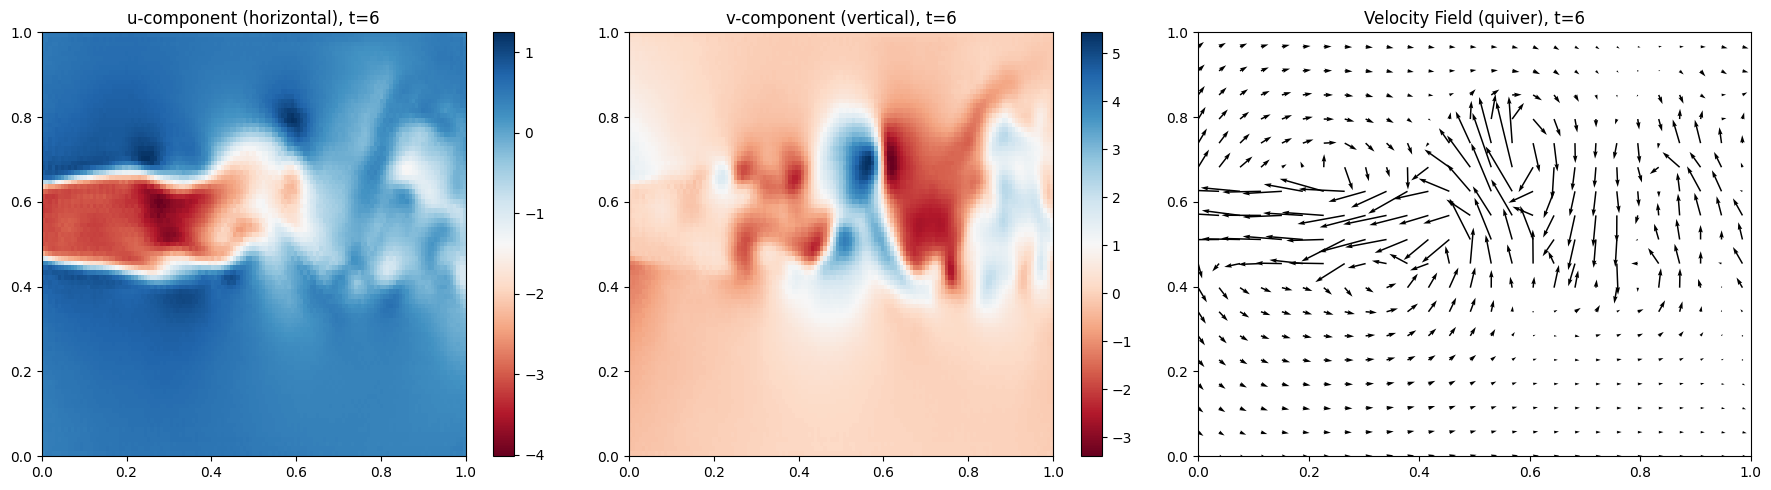

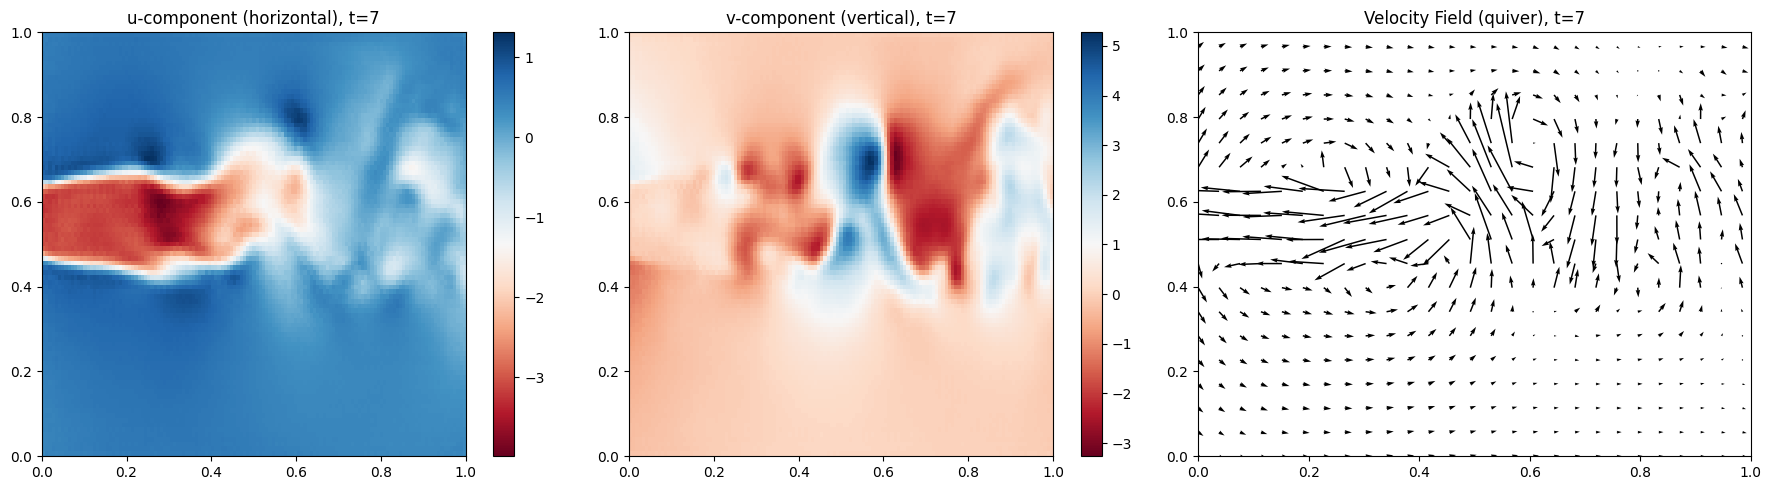

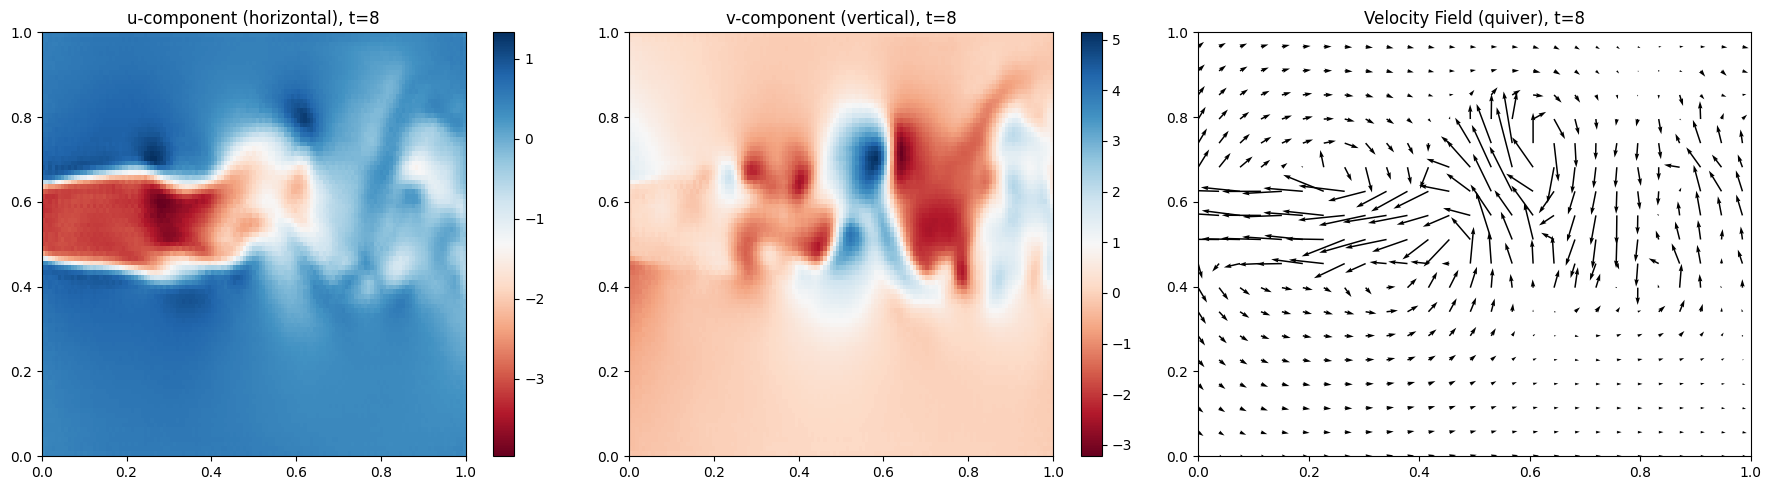

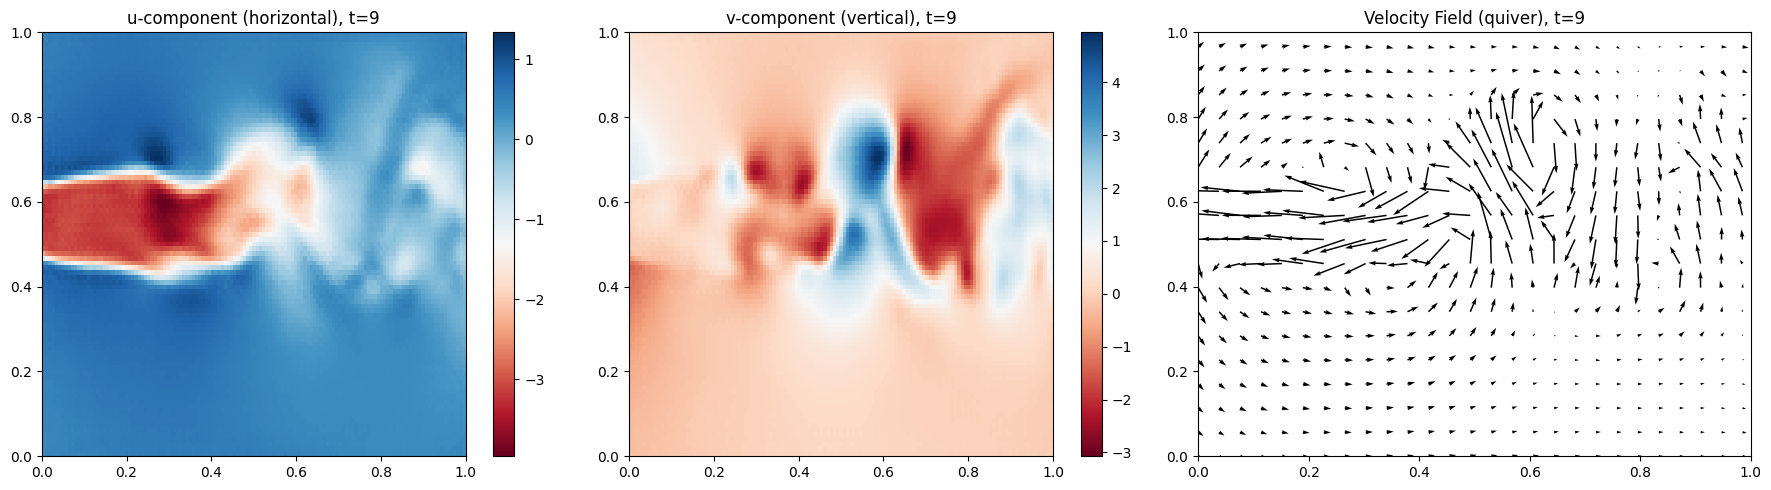

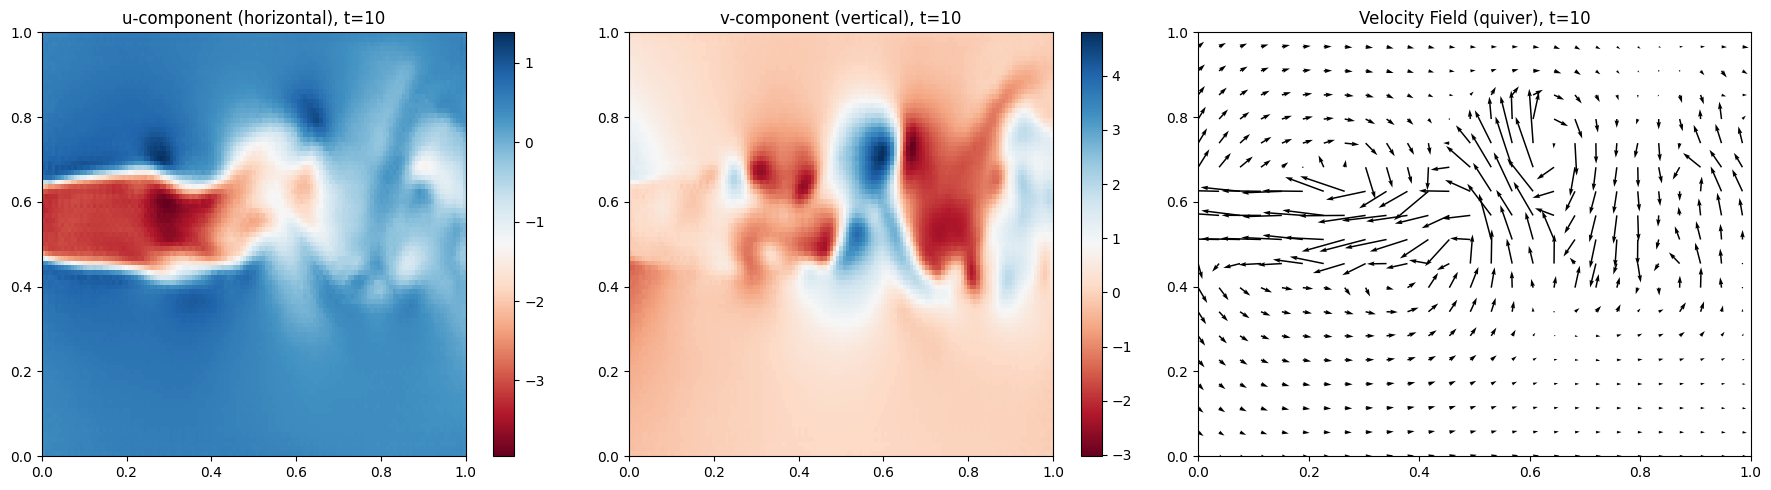

In [ ]:
u_actual, u_pred = test_recursive(model, test_loader)


In [ ]:
from datetime import date

current_date = date.today()
formatted_date = current_date.strftime("%Y%m%d") # YYYY-MM-DD format


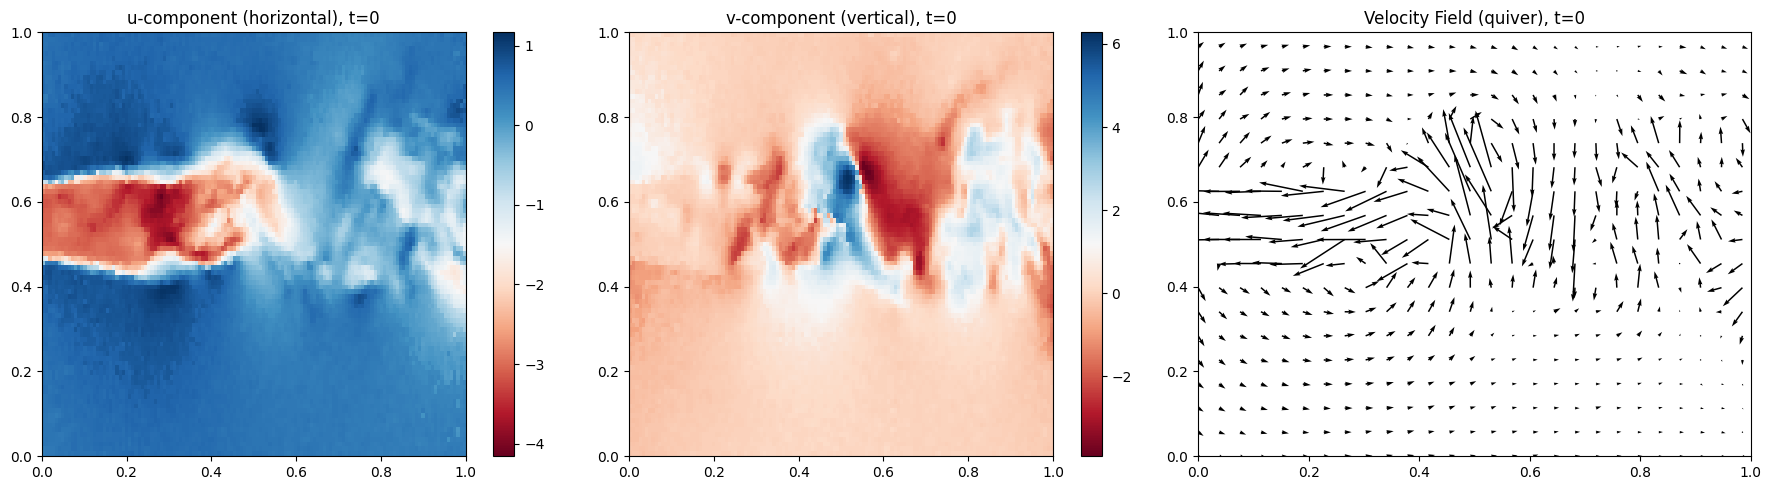

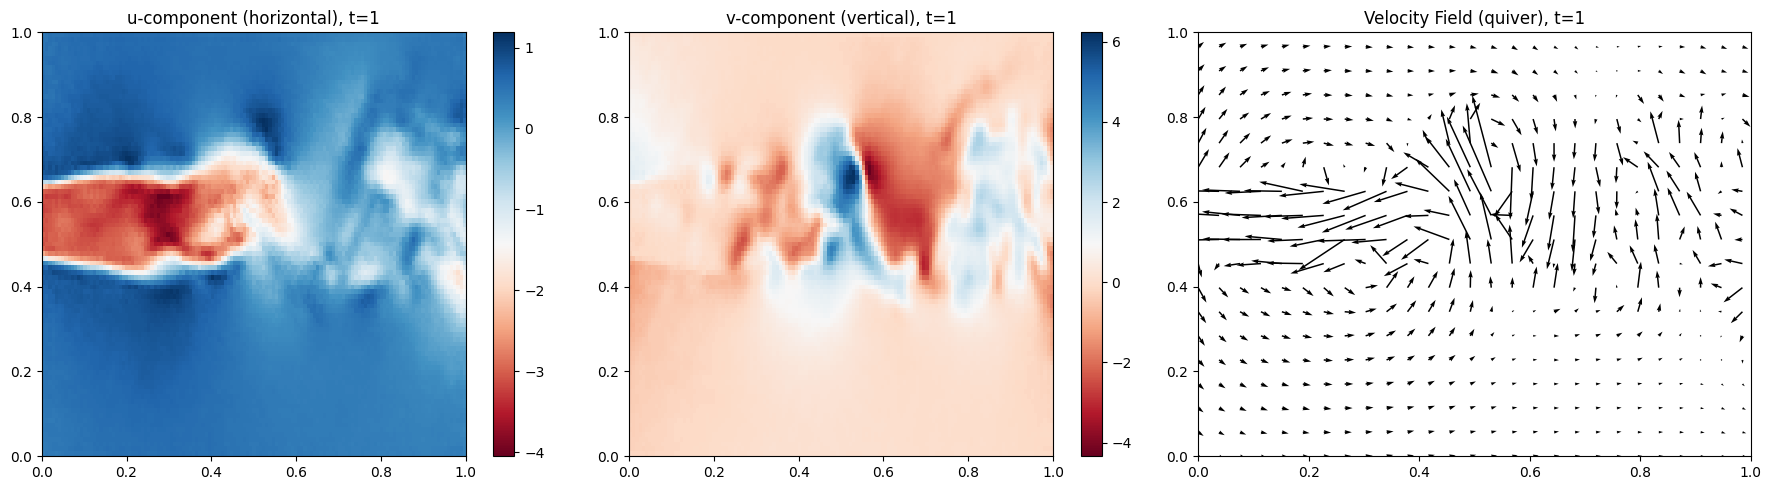

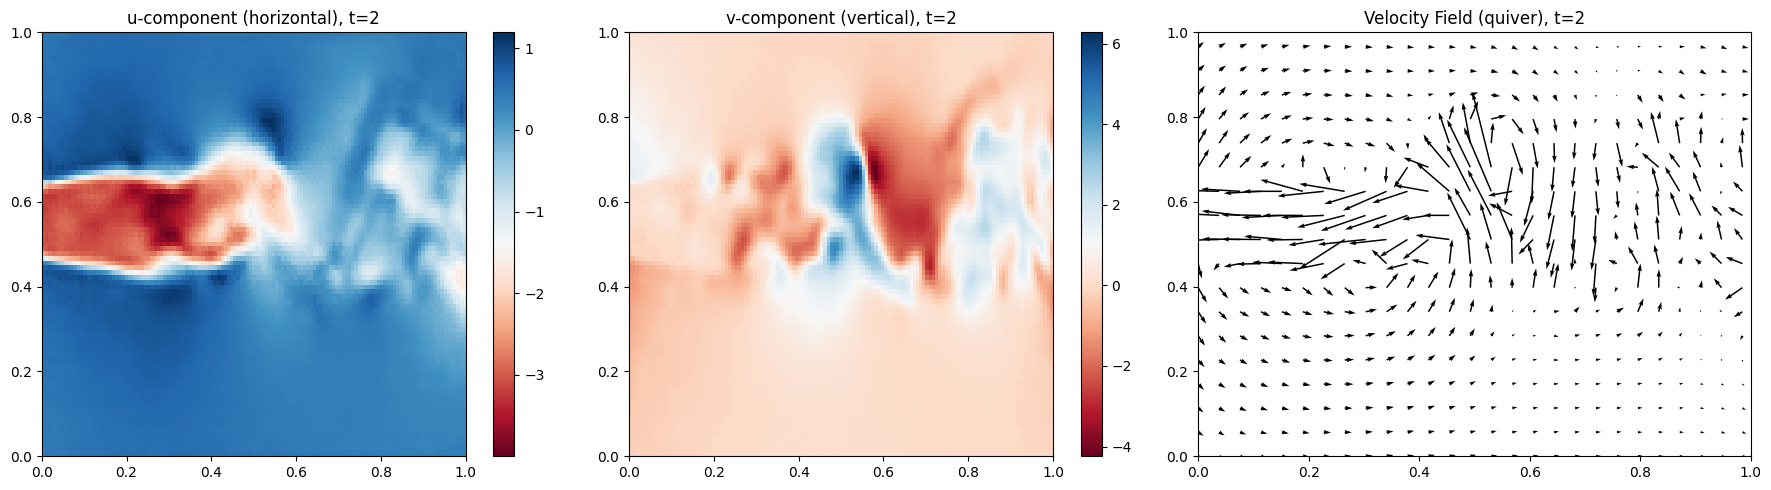

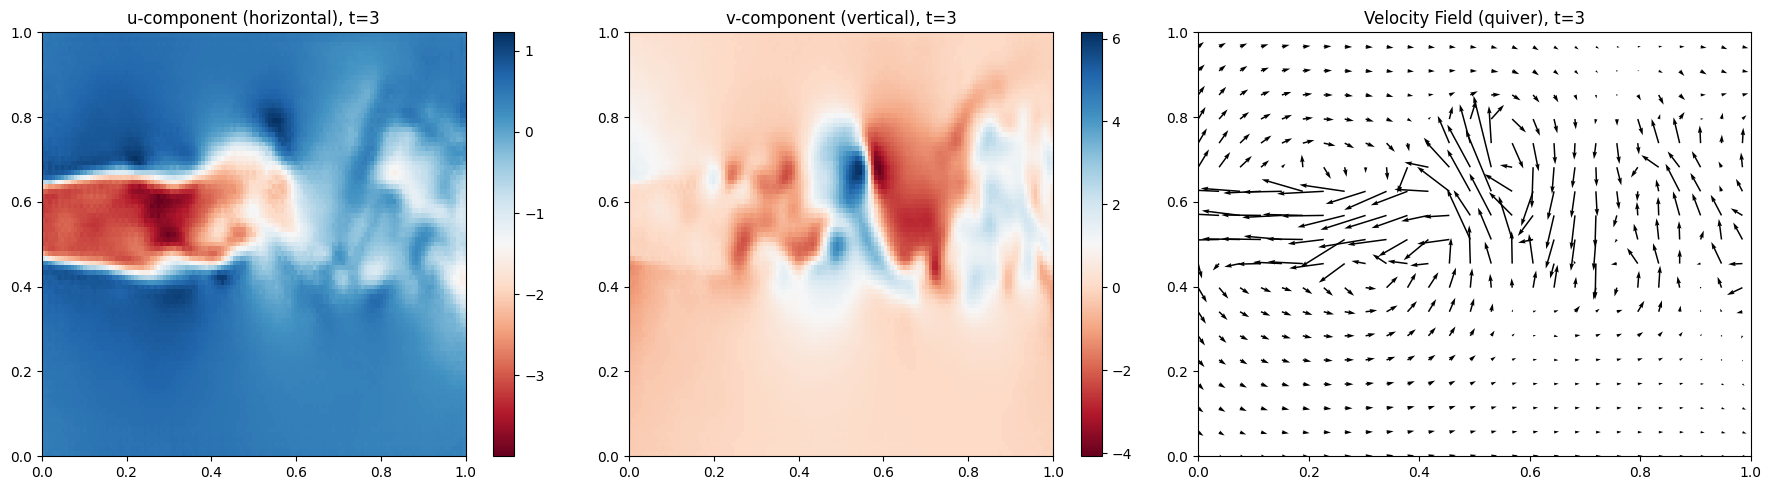

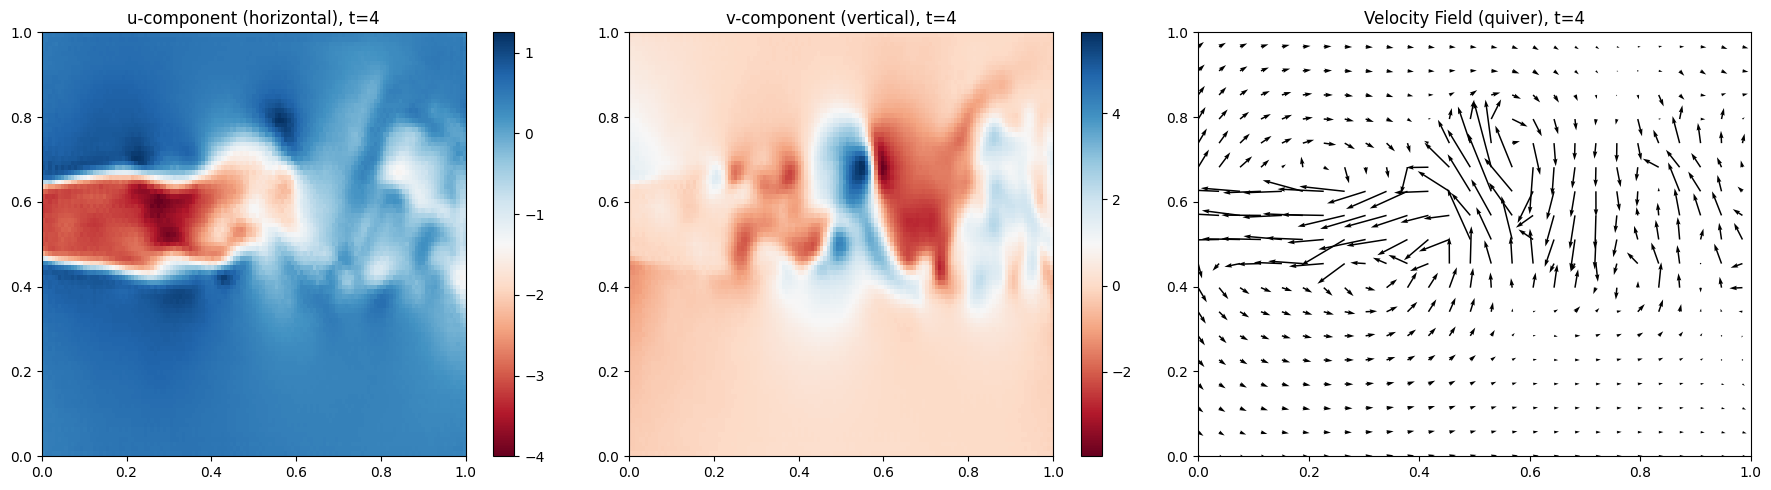

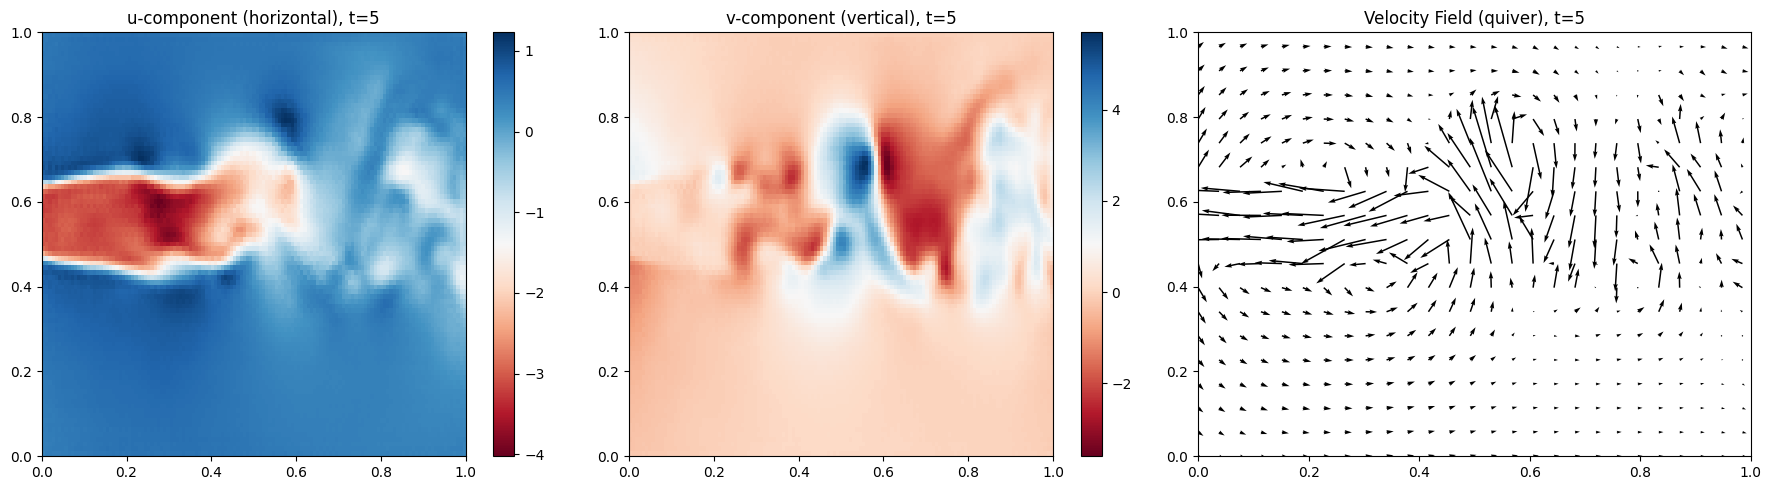

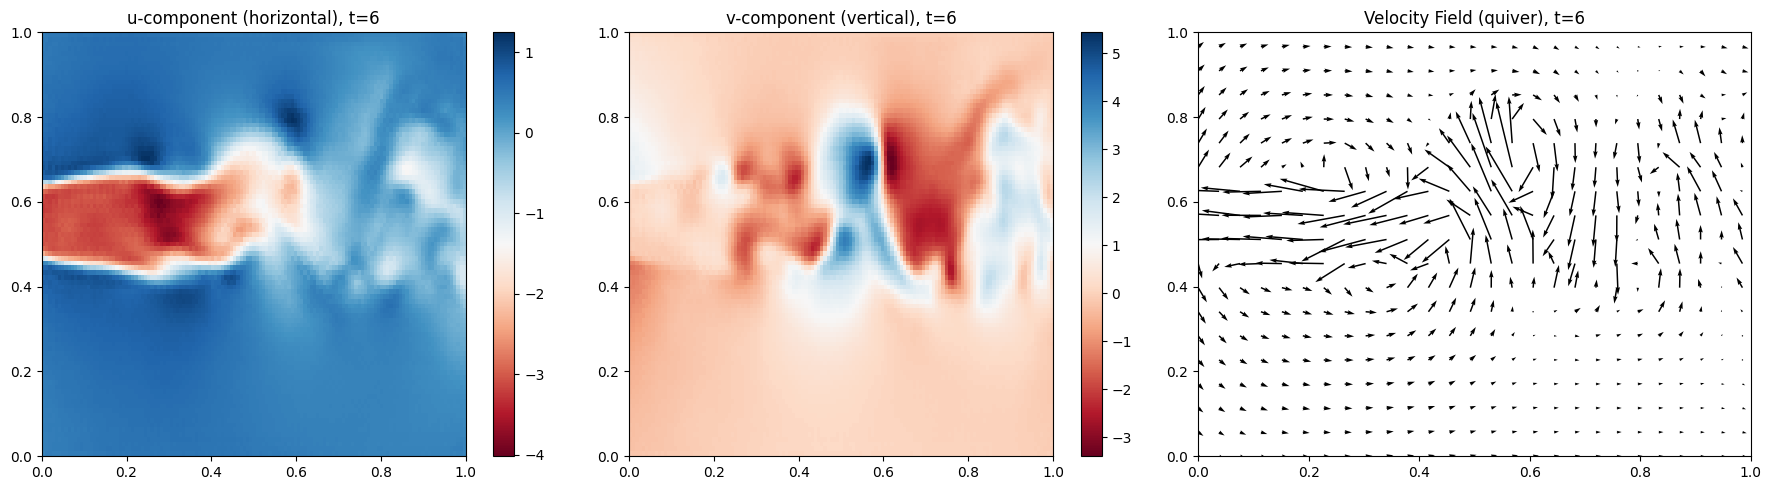

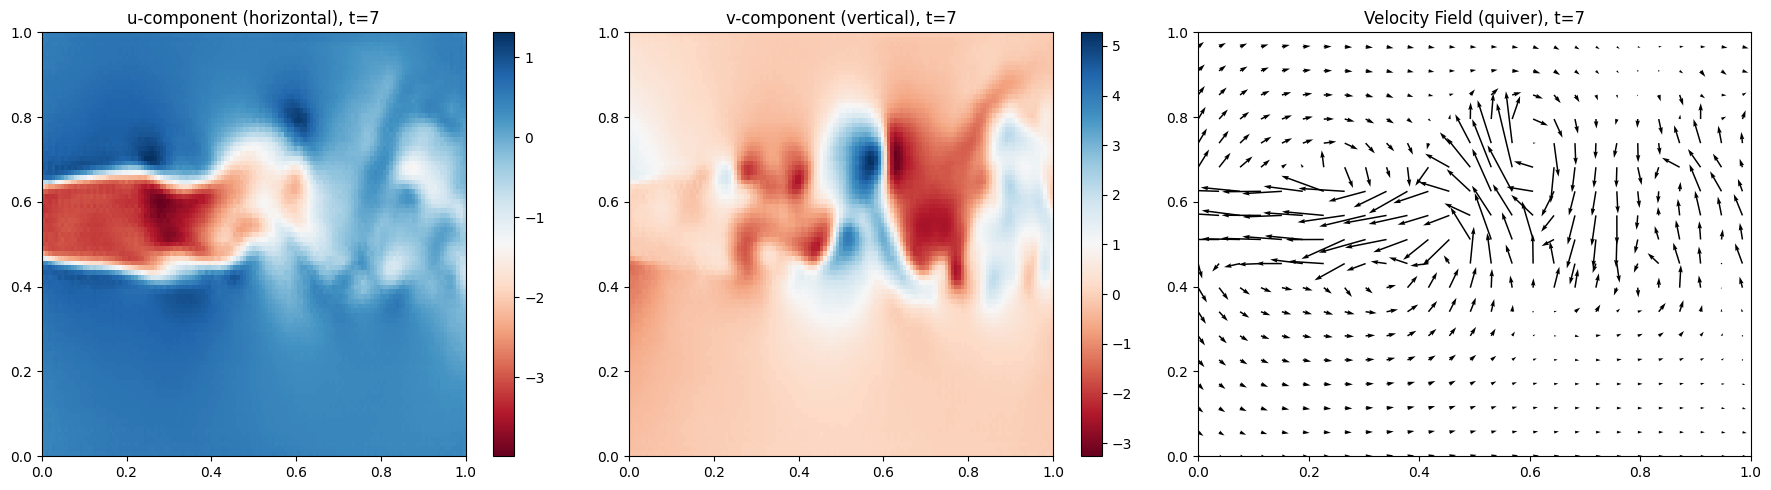

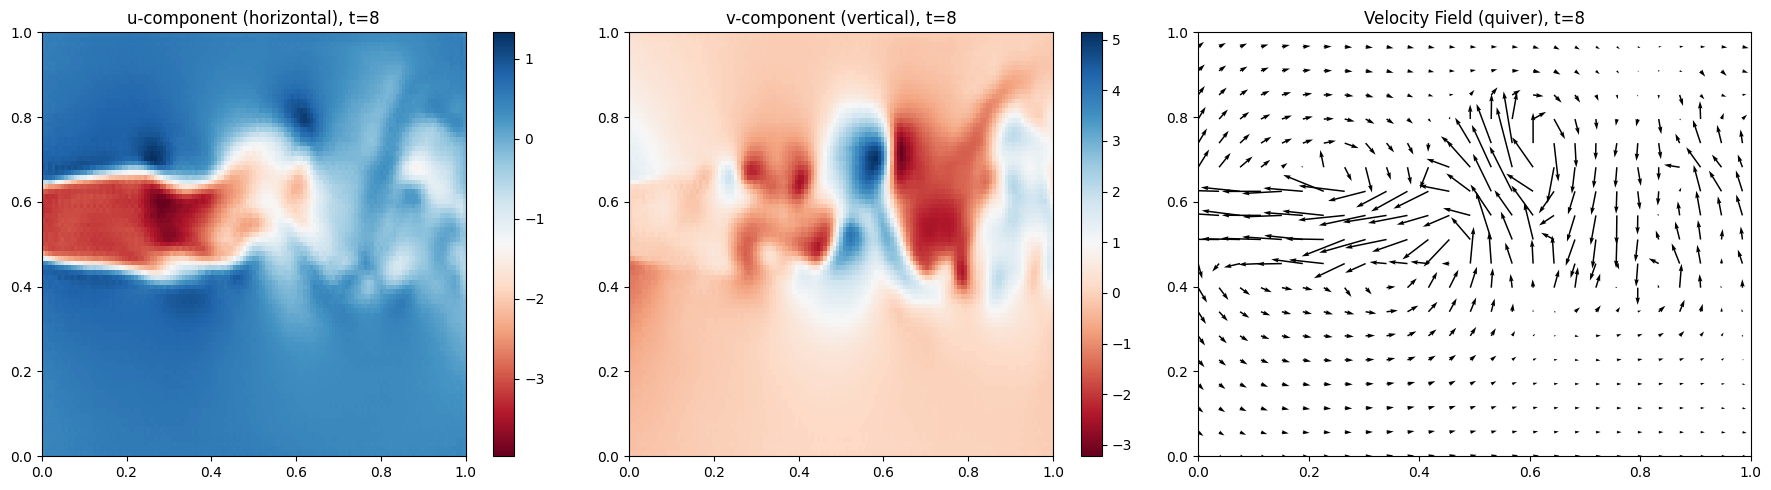

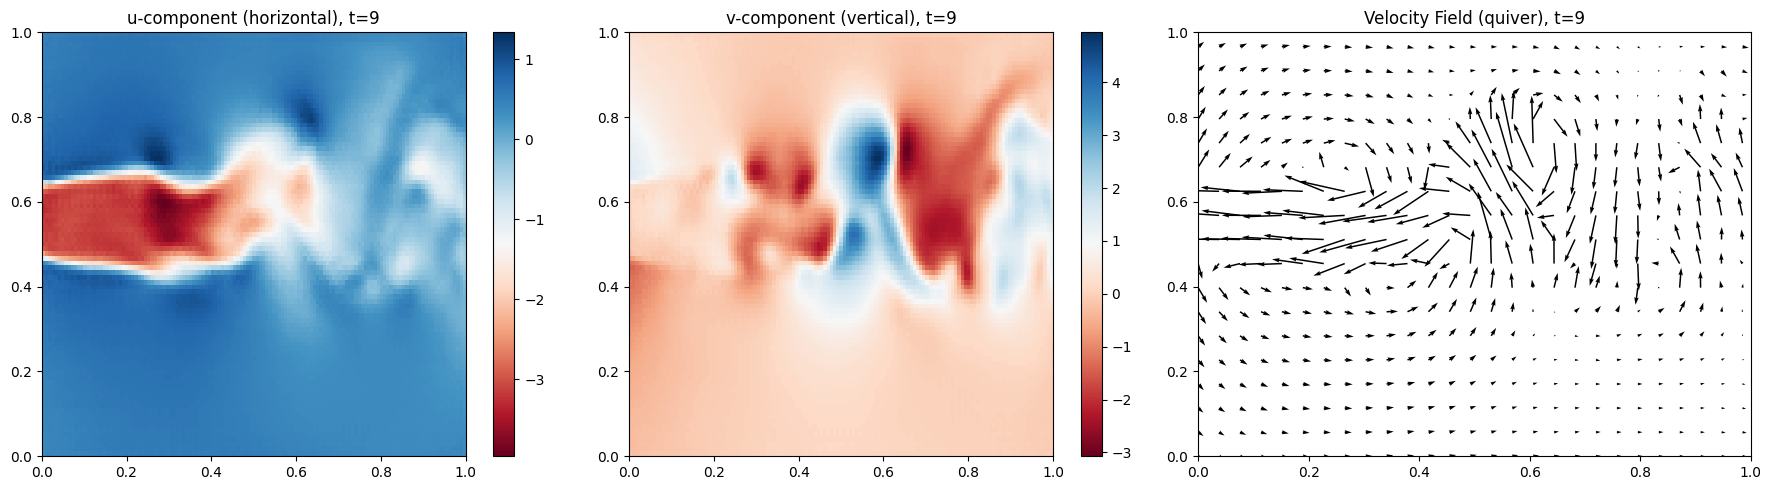

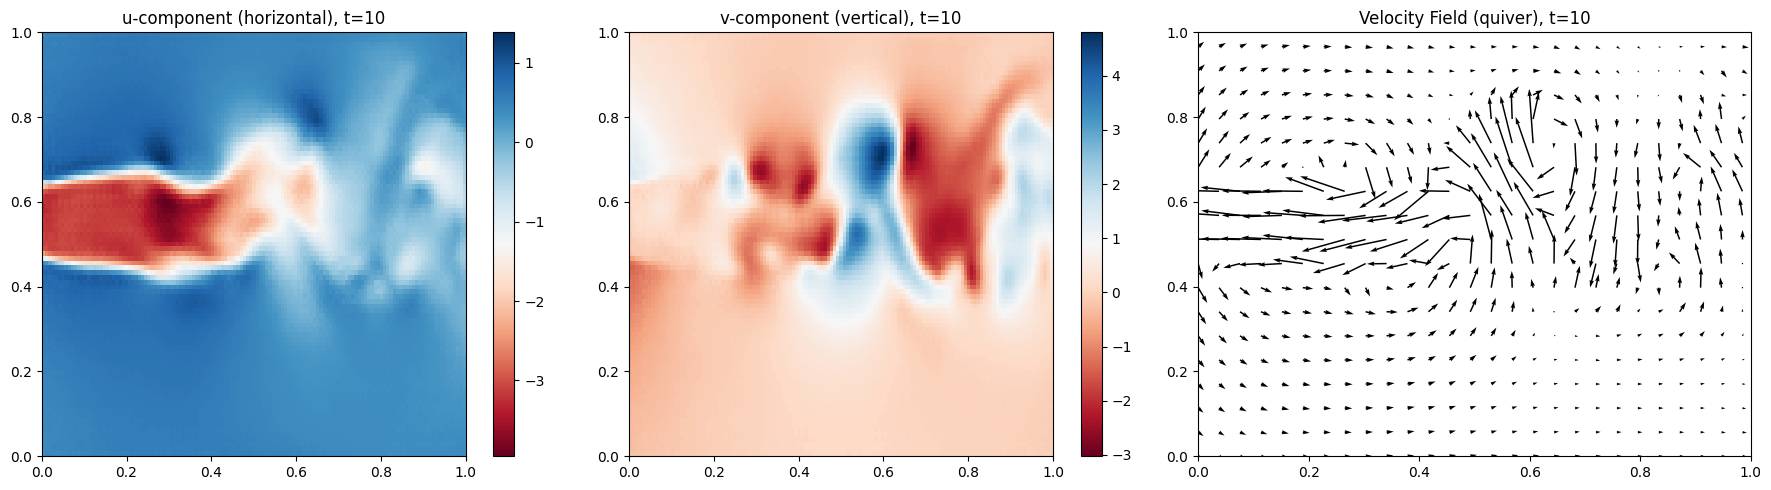

In [ ]:
u_actual, u_pred = test_recursive(model, test_loader)

with h5py.File(f'/content/drive/MyDrive/Research/Winter 2025/FNO/{formatted_date}_UNet_{epochs}_epoch_{batch_size}_{speed}{tags}.h5', 'w') as f:
    f.create_dataset('u_actual', data=u_actual.cpu().numpy())
    f.create_dataset('u_pred', data=u_pred.cpu().numpy())
    f.create_dataset('train_losses', data=np.array(train_losses))
    f.create_dataset('test_losses', data=np.array(test_losses))
    f.create_dataset('best_val_losses', data=np.array(test_losses))
    f.create_dataset('u_x_mean', data=u_x_mean)
    f.create_dataset('u_x_std', data=u_x_std)
    f.create_dataset('u_y_mean', data=u_y_mean)
    f.create_dataset('u_y_std', data=u_y_std)

In [ ]:
path_model = f'/content/drive/MyDrive/Research/Winter 2025/FNO/'
fname = f'{formatted_date}_UNet_{epochs}epoch_{batch_size}_{speed}_{tags}'
if epochs > 5:
    if not os.path.exists(path_model):
        os.makedirs(path_model)
    torch.save(model, path_model + fname)


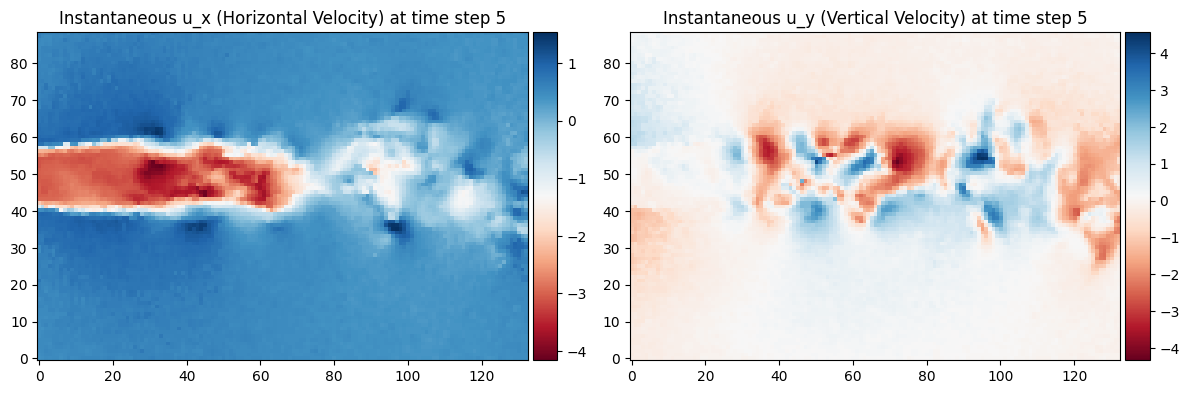

In [ ]:
 from mpl_toolkits.axes_grid1 import make_axes_locatable

# Select a specific time step for the snapshot
time_step = 5 # You can change this to any desired time step within the data range

# Get the instantaneous velocity fields at the selected time step
u_x_snapshot = u_x[0, :, :, time_step].cpu().numpy()
u_y_snapshot = u_y[0, :, :, time_step].cpu().numpy()

# Visualize the instantaneous fields
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Plot u_x_snapshot
im0 = axes[0].imshow(u_x_snapshot, origin="lower", cmap="RdBu")
axes[0].set_title(f"Instantaneous u_x (Horizontal Velocity) at time step {time_step}")
divider0 = make_axes_locatable(axes[0])
cax0 = divider0.append_axes("right", size="5%", pad=0.05)
fig.colorbar(im0, cax=cax0)

# Plot u_y_snapshot
im1 = axes[1].imshow(u_y_snapshot, origin="lower", cmap="RdBu")
axes[1].set_title(f"Instantaneous u_y (Vertical Velocity) at time step {time_step}")
divider1 = make_axes_locatable(axes[1])
cax1 = divider1.append_axes("right", size="5%", pad=0.05)
fig.colorbar(im1, cax=cax1)

plt.tight_layout()
plt.show()

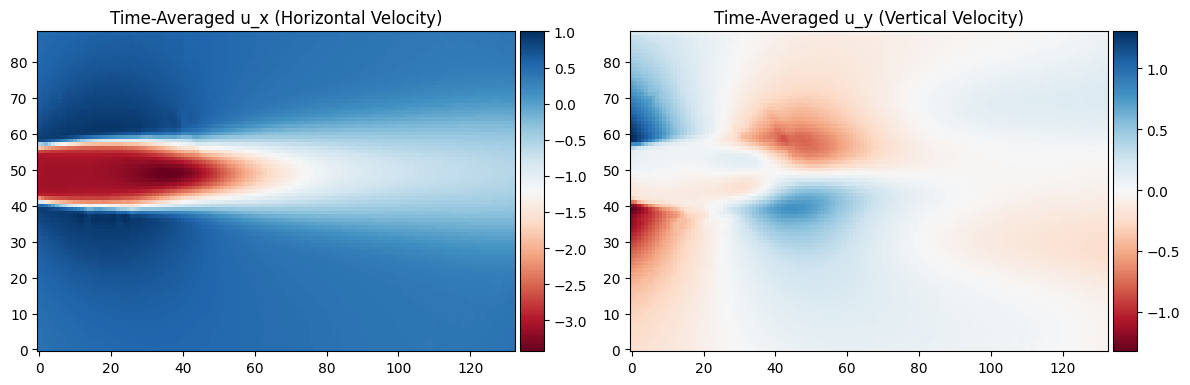

In [ ]:
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Calculate time-averaged velocity fields
u_x_avg = torch.mean(u_x, dim=(0, -1)).cpu().numpy()
u_y_avg = torch.mean(u_y, dim=(0, -1)).cpu().numpy()

# Visualize the time-averaged fields
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Plot u_x_avg
im0 = axes[0].imshow(u_x_avg, origin="lower", cmap="RdBu")
axes[0].set_title("Time-Averaged u_x (Horizontal Velocity)")
divider0 = make_axes_locatable(axes[0])
cax0 = divider0.append_axes("right", size="5%", pad=0.05)
fig.colorbar(im0, cax=cax0)

# Plot u_y_avg
im1 = axes[1].imshow(u_y_avg, origin="lower", cmap="RdBu")
axes[1].set_title("Time-Averaged u_y (Vertical Velocity)")
divider1 = make_axes_locatable(axes[1])
cax1 = divider1.append_axes("right", size="5%", pad=0.05)
fig.colorbar(im1, cax=cax1)

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
plt.plot(u_diff, label="UNet")
plt.ylabel("Error")
plt.xlabel("Timestep")
plt.title("Error of each model at each timestep - 2Hz")
plt.legend()
plt.show()

NameError: name 'u_diff' is not defined